In [ ]:
import os

# 1. Environment & Storage Setup
# Redirect Hugging Face cache to your mounted Windows SSD
os.environ["HF_HOME"] = "/mnt/windows/windows_hanka_bcthesis/llm/huggingface_cache"
# Isolate the RTX 3080 (Assuming it is GPU 0. Change to "1" if it's your second slot)
os.environ["CUDA_VISIBLE_DEVICES"] = "0" 

os.environ["BNB_CUDA_VERSION"] = "121"
# Now we can safely import the deep learning libraries
from unsloth import FastLanguageModel
import torch

# 2. Model Configuration
max_seq_length = 2048 # 2048 is plenty for standard tax cases. Unsloth supports up to 8192+ through RoPE scaling.
dtype = None # Auto-detects bf16/fp16 based on your GPU (RTX 3080 supports bf16)
load_in_4bit = True # Crucial for fitting into 10GB VRAM

#model_name = "unsloth/Meta-Llama-3.1-8B-Instruct-bnb-4bit"
model_name = "unsloth/mistral-7b-instruct-v0.3-bnb-4bit"

print(f"Loading {model_name}...")
model, tokenizer = FastLanguageModel.from_pretrained(
    model_name = model_name,
    max_seq_length = max_seq_length,
    dtype = dtype,
    load_in_4bit = load_in_4bit,
)

# Enable Unsloth's native 2x faster inference mode
FastLanguageModel.for_inference(model)

# 3. Prompt Formatting
# Since your dataset uses "instruction", "input", and "output", the classic Alpaca format is perfect.
mistral_prompt = """Below is an instruction that describes a task, paired with an input that provides further context. Write a response that appropriately completes the request.

### Instruction:
{}

### Input:
{}

### Response:
{}"""

# 4. Test Inference Prompt
test_instruction = "Analysiere den folgenden steuerrechtlichen Sachverhalt und nenne die relevanten österreichischen Paragraphen."
test_input = "Ein selbstständiger IT-Berater kauft einen neuen Laptop für 2.500 Euro, den er zu 80% beruflich und zu 20% privat nutzt. Er möchte wissen, wie er diesen im Rahmen der Einkommensteuererklärung als Betriebsausgabe absetzen kann und ob eine AfA notwendig ist."

# Tokenize and format the prompt
inputs = tokenizer(
    [
        mistral_prompt.format(
            test_instruction,
            test_input,
            "", # Output is left blank for the model to generate
        )
    ], return_tensors = "pt").to("cuda")

print("Generating response...")
# Generate tokens (adjust max_new_tokens based on how verbose you want the output)
outputs = model.generate(**inputs, max_new_tokens = 256, use_cache = True)

# Decode the output
response = tokenizer.batch_decode(outputs, skip_special_tokens = True)[0]

# Extract and print just the generated response
print("\n--- Model Output ---")
print(response.split("### Response:\n")[-1])

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.


[bitsandbytes.cextension|WARNING]WARNING: BNB_CUDA_VERSION=121 environment variable detected; loading libbitsandbytes_cuda121.so.
This can be used to load a bitsandbytes version built with a CUDA version that is different from the PyTorch CUDA version.
If this was unintended set the BNB_CUDA_VERSION variable to an empty string: export BNB_CUDA_VERSION=

[bitsandbytes.cextension|ERROR]bitsandbytes library load error: Configured CUDA binary not found at /home/sj5/.micromamba/envs/llm_course/lib/python3.11/site-packages/bitsandbytes/libbitsandbytes_cuda121.so
Traceback (most recent call last):
  File "/home/sj5/.micromamba/envs/llm_course/lib/python3.11/site-packages/bitsandbytes/cextension.py", line 320, in <module>
    lib = get_native_library()
          ^^^^^^^^^^^^^^^^^^^^
  File "/home/sj5/.micromamba/envs/llm_course/lib/python3.11/site-packages/bitsandbytes/cextension.py", line 288, in get_native_library
    raise RuntimeError(f"Configured {BNB_BACKEND} binary not found at {cuda_bi

Unsloth: Your Flash Attention 2 installation seems to be broken. Using Xformers instead. No performance changes will be seen.
🦥 Unsloth Zoo will now patch everything to make training faster!
Loading unsloth/mistral-7b-instruct-v0.3-bnb-4bit...
==((====))==  Unsloth 2026.4.2: Fast Mistral patching. Transformers: 5.5.0.
   \\   /|    NVIDIA GeForce RTX 3080. Num GPUs = 1. Max memory: 9.885 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0. CUDA: 8.6. CUDA Toolkit: 13.0. Triton: 3.6.0
\        /    Bfloat16 = TRUE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors:   0%|          | 0.00/4.14G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

...

special_tokens_map.json:   0%|          | 0.00/446 [00:00<?, ?B/s]

Both `max_new_tokens` (=256) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Generating response...


/home/sj5/.micromamba/envs/llm_course/lib/python3.11/site-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/home/sj5/.micromamba/envs/llm_course/lib/python3.11/site-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/home/sj5/.micromamba/envs/llm_course/lib/python3.11/site-packages/transformers/modeling_attn_mask_utils.py:254: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`)

CalledProcessError: Command '['/usr/bin/gcc', '/tmp/tmpu_31j03d/cuda_utils.c', '-O3', '-shared', '-fPIC', '-Wno-psabi', '-o', '/tmp/tmpu_31j03d/cuda_utils.cpython-311-x86_64-linux-gnu.so', '-l:libcuda.so.1', '-L/home/sj5/.micromamba/envs/llm_course/lib/python3.11/site-packages/triton/backends/nvidia/lib', '-L/lib64', '-I/home/sj5/.micromamba/envs/llm_course/lib/python3.11/site-packages/triton/backends/nvidia/include', '-I/tmp/tmpu_31j03d', '-I/home/sj5/.micromamba/envs/llm_course/include/python3.11', '-I/home/sj5/.micromamba/envs/llm_course/targets/x86_64-linux/include']' returned non-zero exit status 1.

In [1]:
import os

# 1. Environment & Storage Setup
# Redirect Hugging Face cache to your mounted Windows SSD
os.environ["HF_HOME"] = "/mnt/windows/windows_hanka_bcthesis/llm/huggingface_cache"
# Isolate the RTX 3080 (Assuming it is GPU 0. Change to "1" if it's your second slot)
os.environ["CUDA_VISIBLE_DEVICES"] = "0" 

os.environ["BNB_CUDA_VERSION"] = "121"
# Now we can safely import the deep learning libraries
from unsloth import FastLanguageModel
import torch

# 2. Model Configuration
max_seq_length = 2048 # 2048 is plenty for standard tax cases. Unsloth supports up to 8192+ through RoPE scaling.
dtype = None # Auto-detects bf16/fp16 based on your GPU (RTX 3080 supports bf16)
load_in_4bit = True # Crucial for fitting into 10GB VRAM

#model_name = "unsloth/Meta-Llama-3.1-8B-Instruct-bnb-4bit"
model_name = "unsloth/mistral-7b-instruct-v0.3-bnb-4bit"

print(f"Loading {model_name}...")
model, tokenizer = FastLanguageModel.from_pretrained(
    model_name = model_name,
    max_seq_length = max_seq_length,
    dtype = dtype,
    load_in_4bit = load_in_4bit,
)

# Enable Unsloth's native 2x faster inference mode
FastLanguageModel.for_inference(model)

# 3. Prompt Formatting
# Since your dataset uses "instruction", "input", and "output", the classic Alpaca format is perfect.
mistral_prompt = """Below is an instruction that describes a task, paired with an input that provides further context. Write a response that appropriately completes the request.

### Instruction:
{}

### Input:
{}

### Response:
{}"""

# 4. Test Inference Prompt
test_instruction = "Analysiere den folgenden steuerrechtlichen Sachverhalt und nenne die relevanten österreichischen Paragraphen."
test_input = "Ein selbstständiger IT-Berater kauft einen neuen Laptop für 2.500 Euro, den er zu 80% beruflich und zu 20% privat nutzt. Er möchte wissen, wie er diesen im Rahmen der Einkommensteuererklärung als Betriebsausgabe absetzen kann und ob eine AfA notwendig ist."

# Tokenize and format the prompt
inputs = tokenizer(
    [
        mistral_prompt.format(
            test_instruction,
            test_input,
            "", # Output is left blank for the model to generate
        )
    ], return_tensors = "pt").to("cuda")

print("Generating response...")
# Generate tokens (adjust max_new_tokens based on how verbose you want the output)
outputs = model.generate(**inputs, max_new_tokens = 256, use_cache = True)

# Decode the output
response = tokenizer.batch_decode(outputs, skip_special_tokens = True)[0]

# Extract and print just the generated response
print("\n--- Model Output ---")
print(response.split("### Response:\n")[-1])

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.


[bitsandbytes.cextension|WARNING]WARNING: BNB_CUDA_VERSION=121 environment variable detected; loading libbitsandbytes_cuda121.so.
This can be used to load a bitsandbytes version built with a CUDA version that is different from the PyTorch CUDA version.
If this was unintended set the BNB_CUDA_VERSION variable to an empty string: export BNB_CUDA_VERSION=

[bitsandbytes.cextension|ERROR]bitsandbytes library load error: Configured CUDA binary not found at /home/sj5/.micromamba/envs/llm_course/lib/python3.11/site-packages/bitsandbytes/libbitsandbytes_cuda121.so
Traceback (most recent call last):
  File "/home/sj5/.micromamba/envs/llm_course/lib/python3.11/site-packages/bitsandbytes/cextension.py", line 320, in <module>
    lib = get_native_library()
          ^^^^^^^^^^^^^^^^^^^^
  File "/home/sj5/.micromamba/envs/llm_course/lib/python3.11/site-packages/bitsandbytes/cextension.py", line 288, in get_native_library
    raise RuntimeError(f"Configured {BNB_BACKEND} binary not found at {cuda_bi

Unsloth: Your Flash Attention 2 installation seems to be broken. Using Xformers instead. No performance changes will be seen.
🦥 Unsloth Zoo will now patch everything to make training faster!
Loading unsloth/mistral-7b-instruct-v0.3-bnb-4bit...
==((====))==  Unsloth 2026.4.2: Fast Mistral patching. Transformers: 5.5.0.
   \\   /|    NVIDIA GeForce RTX 3080. Num GPUs = 1. Max memory: 9.885 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0. CUDA: 8.6. CUDA Toolkit: 13.0. Triton: 3.6.0
\        /    Bfloat16 = TRUE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

Both `max_new_tokens` (=256) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Generating response...


/home/sj5/.micromamba/envs/llm_course/lib/python3.11/site-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/home/sj5/.micromamba/envs/llm_course/lib/python3.11/site-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/home/sj5/.micromamba/envs/llm_course/lib/python3.11/site-packages/transformers/modeling_attn_mask_utils.py:254: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`)

RuntimeError: 
🚨 Forgot to compile the bitsandbytes library? 🚨
1. You're not using the package but checked-out the source code
2. You MUST compile from source

Attempted to use bitsandbytes native library functionality but it's not available.

This typically happens when:
1. bitsandbytes doesn't ship with a pre-compiled binary for your CUDA version
2. The library wasn't compiled properly during installation from source

To make bitsandbytes work, the compiled library version MUST exactly match the linked CUDA version.
If your CUDA version doesn't have a pre-compiled binary, you MUST compile from source.

You have two options:
1. COMPILE FROM SOURCE (required if no binary exists):
   https://huggingface.co/docs/bitsandbytes/main/en/installation#cuda-compile
2. Use BNB_CUDA_VERSION to specify a DIFFERENT CUDA version from the detected one, which is installed on your machine and matching an available pre-compiled version listed above

Original error: Configured CUDA binary not found at /h

In [1]:
import os

# 1. Environment & Storage Setup
# Redirect Hugging Face cache to your mounted Windows SSD
os.environ["HF_HOME"] = "/mnt/windows/windows_hanka_bcthesis/llm/huggingface_cache"
# Isolate the RTX 3080 (Assuming it is GPU 0. Change to "1" if it's your second slot)
os.environ["CUDA_VISIBLE_DEVICES"] = "0" 

#os.environ["BNB_CUDA_VERSION"] = "121"
# Now we can safely import the deep learning libraries
from unsloth import FastLanguageModel
import torch

# 2. Model Configuration
max_seq_length = 2048 # 2048 is plenty for standard tax cases. Unsloth supports up to 8192+ through RoPE scaling.
dtype = None # Auto-detects bf16/fp16 based on your GPU (RTX 3080 supports bf16)
load_in_4bit = True # Crucial for fitting into 10GB VRAM

#model_name = "unsloth/Meta-Llama-3.1-8B-Instruct-bnb-4bit"
model_name = "unsloth/mistral-7b-instruct-v0.3-bnb-4bit"

print(f"Loading {model_name}...")
model, tokenizer = FastLanguageModel.from_pretrained(
    model_name = model_name,
    max_seq_length = max_seq_length,
    dtype = dtype,
    load_in_4bit = load_in_4bit,
)

# Enable Unsloth's native 2x faster inference mode
FastLanguageModel.for_inference(model)

# 3. Prompt Formatting
# Since your dataset uses "instruction", "input", and "output", the classic Alpaca format is perfect.
mistral_prompt = """Below is an instruction that describes a task, paired with an input that provides further context. Write a response that appropriately completes the request.

### Instruction:
{}

### Input:
{}

### Response:
{}"""

# 4. Test Inference Prompt
test_instruction = "Analysiere den folgenden steuerrechtlichen Sachverhalt und nenne die relevanten österreichischen Paragraphen."
test_input = "Ein selbstständiger IT-Berater kauft einen neuen Laptop für 2.500 Euro, den er zu 80% beruflich und zu 20% privat nutzt. Er möchte wissen, wie er diesen im Rahmen der Einkommensteuererklärung als Betriebsausgabe absetzen kann und ob eine AfA notwendig ist."

# Tokenize and format the prompt
inputs = tokenizer(
    [
        mistral_prompt.format(
            test_instruction,
            test_input,
            "", # Output is left blank for the model to generate
        )
    ], return_tensors = "pt").to("cuda")

print("Generating response...")
# Generate tokens (adjust max_new_tokens based on how verbose you want the output)
outputs = model.generate(**inputs, max_new_tokens = 256, use_cache = True)

# Decode the output
response = tokenizer.batch_decode(outputs, skip_special_tokens = True)[0]

# Extract and print just the generated response
print("\n--- Model Output ---")
print(response.split("### Response:\n")[-1])

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
Unsloth: Your Flash Attention 2 installation seems to be broken. Using Xformers instead. No performance changes will be seen.
🦥 Unsloth Zoo will now patch everything to make training faster!
Loading unsloth/mistral-7b-instruct-v0.3-bnb-4bit...
==((====))==  Unsloth 2026.4.2: Fast Mistral patching. Transformers: 5.5.0.
   \\   /|    NVIDIA GeForce RTX 3080. Num GPUs = 1. Max memory: 9.885 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 8.6. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

Both `max_new_tokens` (=256) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Generating response...


/home/sj5/.micromamba/envs/llm_course/lib/python3.11/site-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/home/sj5/.micromamba/envs/llm_course/lib/python3.11/site-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/home/sj5/.micromamba/envs/llm_course/lib/python3.11/site-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) 


--- Model Output ---
Der IT-Berater kann den Laptop als Betriebsausgabe absetzen, indem er den Betrag von 2.000 Euro (80% des Gesamtkosten) im Rahmen der Einkommensteuererklärung unter Betriebsausgaben angibt. Dafür sind die Paragraphen 13 UStG (Umsatzsteuergesetz) und 19 Abs. 1 KStG (Körperschaftssteuergesetz) relevant. Eine Abzugsfreistellung (AfA) ist nicht notwendig, da der Laptop nicht als Immobilienkosten abgeschrieben werden kann.


In [1]:
# import os

# # 1. Environment & Storage Setup
# # Redirect Hugging Face cache to your mounted Windows SSD
# os.environ["HF_HOME"] = "/mnt/windows/windows_hanka_bcthesis/llm/huggingface_cache"
# # Isolate the RTX 3080 (Assuming it is GPU 0. Change to "1" if it's your second slot)
# os.environ["CUDA_VISIBLE_DEVICES"] = "0" 
# #os.environ["BNB_CUDA_VERSION"] = "121"

# import polars as pl
# import csv
# from tqdm import tqdm
# # Now we can safely import the deep learning libraries
#from unsloth import FastLanguageModel
# import torch
from llms import evaluator
from llms import mistral

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
Unsloth: Your Flash Attention 2 installation seems to be broken. Using Xformers instead. No performance changes will be seen.
🦥 Unsloth Zoo will now patch everything to make training faster!


In [2]:
mistral = mistral()

In [3]:
INPUT_FILE = "/mnt/red/red_hanka_bcthesis/llm/finetuning_EStGdataset_1.csv"
OUTPUT_FILE = "/mnt/red/red_hanka_bcthesis/llm/mistral_baseline_results_3.csv"

# Config
max_seq_length = 2048 
dtype = None 
load_in_4bit = True 
model_name = "unsloth/mistral-7b-instruct-v0.3-bnb-4bit"

# Strict Prompt
mistral_strict_prompt = """Below is an instruction that describes a task, paired with an input that provides further context. Write a response that appropriately completes the request.

CRITICAL INSTRUCTION: You must respond ONLY with a semicolon-separated list of the relevant Austrian legal paragraphs. Do NOT write any conversational text. Do NOT explain your answer.
Example format: EStG 1988 §4 Abs1; EStG 1988 §16

### Instruction:
{}

### Input:
{}

### Response:
"""

# 1. Load the model and tokenizer into variables
model, tokenizer = mistral.load_model_and_tokenizer(max_seq_length, dtype, load_in_4bit, model_name)

# 2. Pass BOTH into the baseline generator
mistral.generate_mistral_baseline(
    input_csv_path=INPUT_FILE, 
    backup_csv_path=OUTPUT_FILE, 
    prompt_template=mistral_strict_prompt, 
    model=model, 
    tokenizer=tokenizer, 
    limit=200
)

Loading unsloth/mistral-7b-instruct-v0.3-bnb-4bit...
==((====))==  Unsloth 2026.4.2: Fast Mistral patching. Transformers: 5.5.0.
   \\   /|    NVIDIA GeForce RTX 3080. Num GPUs = 1. Max memory: 9.885 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 8.6. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

Loading data from /mnt/red/red_hanka_bcthesis/llm/finetuning_EStGdataset_1.csv...
Starting fresh baseline generation...


Generating Predictions:   0%|          | 0/200 [00:00<?, ?it/s]Both `max_new_tokens` (=64) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
/home/sj5/.micromamba/envs/llm_course/lib/python3.11/site-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/home/sj5/.micromamba/envs/llm_course/lib/python3.11/site-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the ne


 Mistral baseline complete! Results saved to: /mnt/red/red_hanka_bcthesis/llm/mistral_baseline_results_3.csv


**Calculation Precision, Recall and Accuracy in the confusion matrix.**


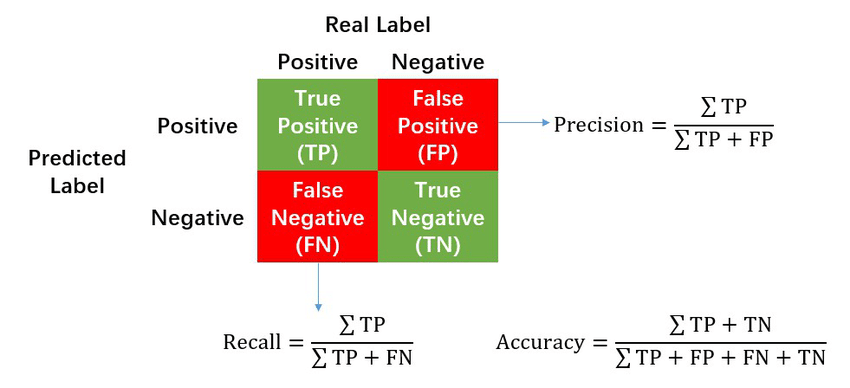

In simple terms:

Recall: how many citations did he predict correctly / how many correct citations are originally there?

Precision: how many citations did he got correct / how many citations did he overall predicted?


Source: Analyzing the Leading Causes of Traffic Fatalities Using XGBoost and Grid-Based Analysis: A City Management Perspective - Scientific Figure on ResearchGate. Available from: https://www.researchgate.net/figure/Calculation-of-Precision-Recall-and-Accuracy-in-the-confusion-matrix_fig3_336402347 [accessed 6 Apr 2026]

In [4]:
results_csv_path = "/mnt/red/red_hanka_bcthesis/llm/mistral_baseline_results_3.csv"
evaluator = evaluator(results_csv_path=results_csv_path)

In [5]:
# Run the evaluation on your Mistral output
results_csv_path = "/mnt/red/red_hanka_bcthesis/llm/mistral_baseline_results_2.csv"
outputpath = "/mnt/red/red_hanka_bcthesis/llm/eval_mistral_bsl_1.csv"
evaluator.evaluate_results(output_path = None, results_csv_path = results_csv_path)

Loading results from /mnt/red/red_hanka_bcthesis/llm/mistral_baseline_results_2.csv...
shape: (2, 10)
┌────────────┬────────────┬───────────┬───────────┬───┬───────────┬───────────┬───────────┬────────┐
│ id         ┆ instructio ┆ input     ┆ ground_tr ┆ … ┆ pred_list ┆ exact_mat ┆ precision ┆ recall │
│ ---        ┆ n          ┆ ---       ┆ uth_label ┆   ┆ ---       ┆ ch        ┆ ---       ┆ ---    │
│ str        ┆ ---        ┆ str       ┆ ---       ┆   ┆ list[str] ┆ ---       ┆ f64       ┆ f64    │
│            ┆ str        ┆           ┆ str       ┆   ┆           ┆ bool      ┆           ┆        │
╞════════════╪════════════╪═══════════╪═══════════╪═══╪═══════════╪═══════════╪═══════════╪════════╡
│ JWR_201915 ┆ Analysiere ┆ 1 Die rev ┆ EStG 1988 ┆ … ┆ ["EStG    ┆ false     ┆ 0.0       ┆ 0.0    │
│ 0007_20210 ┆ den        ┆ isionswer ┆ §4 Abs1;  ┆   ┆ 1988 §    ┆           ┆           ┆        │
│ 610J01     ┆ folgenden  ┆ bende     ┆ EStG 1988 ┆   ┆ 1a",      ┆           ┆           

In [5]:
# Run the evaluation on your Mistral output
results_csv_path = "/mnt/red/red_hanka_bcthesis/llm/mistral_baseline_results_3.csv"
outputpath = "/mnt/red/red_hanka_bcthesis/llm/eval_mistral_bsl_2.csv"
evaluator.evaluate_results(output_path = outputpath, results_csv_path = results_csv_path)

Loading results from /mnt/red/red_hanka_bcthesis/llm/mistral_baseline_results_3.csv...
shape: (200, 10)
┌───────────┬───────────┬───────────┬───────────┬───┬───────────┬───────────┬───────────┬──────────┐
│ id        ┆ instructi ┆ input     ┆ ground_tr ┆ … ┆ pred_list ┆ exact_mat ┆ precision ┆ recall   │
│ ---       ┆ on        ┆ ---       ┆ uth_label ┆   ┆ ---       ┆ ch        ┆ ---       ┆ ---      │
│ str       ┆ ---       ┆ str       ┆ ---       ┆   ┆ list[str] ┆ ---       ┆ f64       ┆ f64      │
│           ┆ str       ┆           ┆ str       ┆   ┆           ┆ bool      ┆           ┆          │
╞═══════════╪═══════════╪═══════════╪═══════════╪═══╪═══════════╪═══════════╪═══════════╪══════════╡
│ JWR_20191 ┆ Analysier ┆ 1 Die rev ┆ EStG 1988 ┆ … ┆ ["EStG    ┆ false     ┆ 0.0       ┆ 0.0      │
│ 50007_202 ┆ e den     ┆ isionswer ┆ §4 Abs1;  ┆   ┆ 1988 §    ┆           ┆           ┆          │
│ 10610J01  ┆ folgenden ┆ bende     ┆ EStG 1988 ┆   ┆ 1a",      ┆           ┆           

In [9]:
# 1. Create the Dummy Data
dummy_data = {
    "id": [
        "1",
        "2",
        "3",
        "4",
        "5"
    ],
    "instruction": [
        "Test it",
        "Test it",
        "Test it",
        "Test it",
        "Test it"
    ],
    "input": [
        "Perfect Match (Order doesn't matter)",
        "Partial Match (Model missed one)",
        "Hallucination (Model added a wrong one)",
        "Complete Miss",
        "Empty Response"
    ],
    "ground_truth_label": [
        "EStG §4; BAO §9",
        "EStG §4; EStG §5; EStG §6",
        "EStG §4",
        "EStG §10",
        "EStG §1"
    ],
    "raw_model_response": [
        "BAO §9; EStG §4",      # Should be 100%
        "EStG §4; EStG §5",      # Should be 66% Recall, 100% Precision
        "EStG §4; KStG §20",     # Should be 100% Recall, 50% Precision
        "UStG §1",               # Should be 0% everything
        ""                       # Should be 0% everything
    ]
}

df_dummy = pl.DataFrame(dummy_data)
df_dummy

id,instruction,input,ground_truth_label,raw_model_response
str,str,str,str,str
"""1""","""Test it""","""Perfect Match (Order doesn't m…","""EStG §4; BAO §9""","""BAO §9; EStG §4"""
"""2""","""Test it""","""Partial Match (Model missed on…","""EStG §4; EStG §5; EStG §6""","""EStG §4; EStG §5"""
"""3""","""Test it""","""Hallucination (Model added a w…","""EStG §4""","""EStG §4; KStG §20"""
"""4""","""Test it""","""Complete Miss""","""EStG §10""","""UStG §1"""
"""5""","""Test it""","""Empty Response""","""EStG §1""",""""""


In [10]:
evaluator.evaluate_results(results_df=df_dummy, output_path = None)

shape: (5, 10)
┌─────┬─────────────┬────────────┬────────────┬───┬────────────┬────────────┬───────────┬──────────┐
│ id  ┆ instruction ┆ input      ┆ ground_tru ┆ … ┆ pred_list  ┆ exact_matc ┆ precision ┆ recall   │
│ --- ┆ ---         ┆ ---        ┆ th_label   ┆   ┆ ---        ┆ h          ┆ ---       ┆ ---      │
│ str ┆ str         ┆ str        ┆ ---        ┆   ┆ list[str]  ┆ ---        ┆ f64       ┆ f64      │
│     ┆             ┆            ┆ str        ┆   ┆            ┆ bool       ┆           ┆          │
╞═════╪═════════════╪════════════╪════════════╪═══╪════════════╪════════════╪═══════════╪══════════╡
│ 1   ┆ Test it     ┆ Perfect    ┆ EStG §4;   ┆ … ┆ ["BAO §9", ┆ true       ┆ 1.0       ┆ 1.0      │
│     ┆             ┆ Match      ┆ BAO §9     ┆   ┆ "EStG §4"] ┆            ┆           ┆          │
│     ┆             ┆ (Order     ┆            ┆   ┆            ┆            ┆           ┆          │
│     ┆             ┆ doesn't m… ┆            ┆   ┆            ┆            

In [1]:
import polars as pl
estg = pl.read_csv("/mnt/red/red_hanka_bcthesis/llm/finetuning_EStGdataset_1.csv")
estg

id,instruction,input,output
str,str,str,str
"""JWR_2019150007_20210610J01""","""Analysiere den folgenden steue…","""1 Die revisionswerbende Gesell…","""EStG 1988 §4 Abs1; EStG 1988 §…"
"""JWR_2004150001_20090422X01""","""Analysiere den folgenden steue…","""Im August 2000 langte beim Fin…","""; EStG 1988 §47 Abs2"""
"""JWR_2008150335_20100520X01""","""Analysiere den folgenden steue…","""Mit dem im Instanzenzug ergang…","""; EStG 1988 §16; EStG 1988 §16…"
"""JWR_2006150238_20100520X01""","""Analysiere den folgenden steue…","""Beim Beschwerdeführer, einem E…","""; EStG 1988 §4"""
"""JWR_2017150066_20181219L01""","""Analysiere den folgenden steue…","""1 Der ursprünglich in den USA …","""; EStG 1988 §34 Abs8"""
…,…,…,…
"""JWR_2009150194_20120426X01""","""Analysiere den folgenden steue…","""Der Beschwerdeführer erwarb 19…","""; EStG 1988 §2 Abs3 Z6; EStG 1…"
"""JWR_2013150262_20160915X01""","""Analysiere den folgenden steue…","""1 Im Rahmen der Schlussbesprec…","""; EStG 1988 §47 Abs2; KommStG …"
"""JWR_2006150037_20080827X01""","""Analysiere den folgenden steue…","""Der Beschwerdeführer betreibt …","""; BAO §115 Abs1; BAO §167 Abs2…"
